# Octree Refine (L3–L1 Shared) — Architecture Shootout

This notebook tests candidate architectures for **Model B (`octree_refine`)**, the shared refinement
model that operates at L3, L2, and L1 with a level embedding differentiating them.

## Candidates

| ID | Parent Injection | Channels | Level Embedding | Rationale |
|----|-----------------|----------|-----------------|-----------|
| B1 | Concat (parent as input channels) | [32,64,128] | Additive | Simplest — parent is just more input |
| B2 | FiLM conditioning (parent modulates BN) | [32,64,128] | FiLM | Multiplicative interaction may be richer |
| B3 | Cross-attention (decoder attends over parent) | [32,64,128] | Additive | Most expressive but heaviest |
| B4 | Concat (wider) | [48,96,192] | Additive | More capacity, same simple strategy |

## Level Embedding Secondary Test
After the main shootout, the winner is retested with 3 level embedding strategies:
- **Additive**: level embedding added to encoder features
- **Concat**: level embedding concatenated as extra channel
- **FiLM**: level embedding modulates BN via scale/shift

## Metrics
- Per-level block accuracy (L3 vs L2 vs L1)
- Occupancy F1 (precision, recall)
- Inference latency (CPU)
- Parameter count

In [1]:
from __future__ import annotations

import importlib
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import octree_shootout_utils as shootout_utils

importlib.reload(shootout_utils)

from octree_shootout_utils import (
    ARTIFACT_DIR,
    DATA_DIR,
    DEVICE,
    NUM_BIOMES,
    NUM_BLOCK_CLASSES,
    NUM_LEVELS,
    NUM_Y_POSITIONS,
    ROOT,
    SEED,
    SPATIAL,
    benchmark_latency as shared_benchmark_latency,
    bitmask_to_binary,
    compute_block_log_priors,
    compute_block_metrics,
    compute_occ_metrics,
    cross_entropy_loss,
    describe_split,
    init_block_head_bias,
    load_pair_cache_subset,
    make_loader,
    maybe_corrupt_parent,
    maybe_load_class_weights,
    occupancy_loss,
    seed_everything,
)

seed_everything(SEED)
CLASS_WEIGHTS = maybe_load_class_weights(DATA_DIR)

VOXEL_SIZE = {4: 16, 3: 8, 2: 4, 1: 2, 0: 1}

print("ROOT =", ROOT)
print("DATA_DIR =", DATA_DIR)
print("DEVICE =", DEVICE)
print("CLASS_WEIGHTS =", None if CLASS_WEIGHTS is None else tuple(CLASS_WEIGHTS.shape))

ROOT = c:\Users\JeffHall\git\MC\VoxelTree
DATA_DIR = c:\Users\JeffHall\git\MC\VoxelTree\data\voxy_octree
DEVICE = cpu
CLASS_WEIGHTS = None


## Data Loading

Load real L3/L2/L1 training data from the production pair caches. Each sample includes:
- `labels32`: target 32³ block IDs
- `parent_labels32`: parent octant upsampled 2× to 32³
- `heightmap32`: 5-channel height features
- `biome32`: biome indices
- `y_position`: section Y coordinate
- `level`: LOD level `(1, 2, or 3)`
- `non_empty_children`: 8-bit occupancy mask

If the pair caches are missing, the notebook now fails immediately instead of falling back to synthetic data.

In [2]:
AIR = 0
STONE = 1
DIRT = 3
GRASS_BLOCK = 9
SAND = 66
WATER = 34
DEEPSLATE = 899


def load_refine_data() -> tuple[dict, dict]:
    train_data = load_pair_cache_subset(
        "train", levels=[1, 2, 3], include_parent=True, include_level=True, include_occ=True
    )
    val_data = load_pair_cache_subset(
        "val", levels=[1, 2, 3], include_parent=True, include_level=True, include_occ=True
    )
    if train_data is None or val_data is None:
        raise FileNotFoundError(
            "Missing required pair caches for refine shootout. Expected "
            "data/voxy_octree/train_octree_pairs.npz and val_octree_pairs.npz."
        )
    print("Loaded production pair caches for L3/L2/L1 refine shootout.")
    return train_data, val_data


def subsample_per_level(
    data: dict[str, np.ndarray],
    *,
    max_per_level: int | None,
    seed: int = SEED,
    levels: tuple[int, ...] = (1, 2, 3),
) -> dict[str, np.ndarray]:
    if max_per_level is None:
        return data

    level_arr = data["level"].astype(np.int64)
    rng = np.random.default_rng(seed)
    keep_parts: list[np.ndarray] = []
    for level in levels:
        idx = np.where(level_arr == level)[0]
        if len(idx) == 0:
            continue
        if len(idx) > max_per_level:
            idx = rng.choice(idx, size=max_per_level, replace=False)
        keep_parts.append(np.sort(idx))

    if not keep_parts:
        raise ValueError("No samples selected after per-level subsampling.")

    keep_idx = np.concatenate(keep_parts)
    keep_idx.sort()
    return {k: v[keep_idx] for k, v in data.items()}


train_data, val_data = load_refine_data()

# Quick-shootout controls (real data only; no synthetic fallback).
TRAIN_MAX_PER_LEVEL = 256
VAL_MAX_PER_LEVEL = None

train_data = subsample_per_level(train_data, max_per_level=TRAIN_MAX_PER_LEVEL, seed=SEED)
val_data = subsample_per_level(val_data, max_per_level=VAL_MAX_PER_LEVEL, seed=SEED + 1)

BLOCK_LOG_PRIORS = compute_block_log_priors(
    train_data["labels32"],
    num_classes=NUM_BLOCK_CLASSES,
)

print(
    f"Using per-level caps → train: {TRAIN_MAX_PER_LEVEL}, "
    f"val: {'full' if VAL_MAX_PER_LEVEL is None else VAL_MAX_PER_LEVEL}"
)
describe_split("train", train_data, show_levels=True)
describe_split("val", val_data, show_levels=True)

Loaded production pair caches for L3/L2/L1 refine shootout.
Computed block priors: total_voxels=21,331,968 air=61.51% seen=210/1104
Using per-level caps → train: 256, val: full
train:
  labels32: shape=(651, 32, 32, 32) dtype=int32
  heightmap32: shape=(651, 5, 32, 32) dtype=float32
  biome32: shape=(651, 32, 32) dtype=int32
  y_position: shape=(651,) dtype=int64
  parent_labels32: shape=(651, 32, 32, 32) dtype=int32
  level: shape=(651,) dtype=int64
  non_empty_children: shape=(651,) dtype=uint8
  levels: {1: 256, 2: 256, 3: 139}
val:
  labels32: shape=(196, 32, 32, 32) dtype=int32
  heightmap32: shape=(196, 5, 32, 32) dtype=float32
  biome32: shape=(196, 32, 32) dtype=int32
  y_position: shape=(196,) dtype=int64
  parent_labels32: shape=(196, 32, 32, 32) dtype=int32
  level: shape=(196,) dtype=int64
  non_empty_children: shape=(196,) dtype=uint8
  levels: {1: 171, 2: 20, 3: 5}


In [3]:
# ── Data sanity checks ─────────────────────────────────────────────
labels = train_data["labels32"]
parent = train_data["parent_labels32"]
print(f"Air fraction (target): {(labels == AIR).mean():.3f}")
print(f"Air fraction (parent): {(parent == AIR).mean():.3f}")
print(f"Parent-target agreement: {(labels == parent).mean():.3f}")
print(
    f'Non-empty children mean bits: {np.mean([bin(x).count("1") for x in train_data["non_empty_children"]]):.1f}'
)

Air fraction (target): 0.615
Air fraction (parent): 0.640
Parent-target agreement: 0.866
Non-empty children mean bits: 5.7


In [4]:
BATCH_SIZE = 8
train_loader = make_loader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    include_parent=True,
    include_level=True,
    include_occ=True,
)
val_loader = make_loader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    include_parent=True,
    include_level=True,
    include_occ=True,
)

batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"{k}: {tuple(v.shape)} {v.dtype}")

labels32: (8, 32, 32, 32) torch.int64
heightmap32: (8, 5, 32, 32) torch.float32
biome32: (8, 32, 32) torch.int64
y_position: (8,) torch.int64
parent_labels32: (8, 32, 32, 32) torch.int64
level: (8,) torch.int64
non_empty_children: (8,) torch.int64


## Building Blocks

Shared components for all refine model candidates.

In [5]:
class Conv3dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DoubleConv3d(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(Conv3dBlock(in_ch, out_ch), Conv3dBlock(out_ch, out_ch))

    def forward(self, x):
        return self.block(x)


class OccupancyHead(nn.Module):
    """Spatial octant pooling → shared MLP → 8 logits."""

    def __init__(self, in_ch: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_ch, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz, channels = x.shape[:2]
        pooled = x.reshape(bsz, channels, 2, 4, 2, 4, 2, 4).mean(dim=(3, 5, 7))
        pooled = pooled.reshape(bsz, channels, 8).permute(0, 2, 1)
        return self.mlp(pooled).squeeze(-1)


class ParentEncoder(nn.Module):
    """Embed parent block IDs into a dense 3D feature volume."""

    def __init__(self, out_ch: int, embed_dim: int = 16):
        super().__init__()
        self.block_emb = nn.Embedding(NUM_BLOCK_CLASSES, embed_dim)
        self.conv = nn.Sequential(
            nn.Conv3d(embed_dim, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, parent_labels: torch.Tensor) -> torch.Tensor:
        emb = self.block_emb(parent_labels.clamp(0, NUM_BLOCK_CLASSES - 1))
        emb = emb.permute(0, 4, 1, 2, 3)
        return self.conv(emb)


class ConditioningEncoder2D(nn.Module):
    """Encode heightmap + biome → 2D features → expand to 3D volume."""

    def __init__(self, out_ch: int, biome_dim: int = 8, y_dim: int = 8):
        super().__init__()
        self.biome_emb = nn.Embedding(NUM_BIOMES, biome_dim)
        self.y_emb = nn.Embedding(NUM_Y_POSITIONS, y_dim)
        self.conv2d = nn.Sequential(
            nn.Conv2d(5 + biome_dim, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.y_proj = nn.Linear(y_dim, out_ch)

    def forward(self, hm, biome, y_pos):
        bsz = hm.shape[0]
        biome_feat = self.biome_emb(biome.clamp(0, NUM_BIOMES - 1)).permute(0, 3, 1, 2)
        cond_2d = self.conv2d(torch.cat([hm, biome_feat], dim=1))
        cond_3d = cond_2d.unsqueeze(2).expand(-1, -1, SPATIAL, -1, -1)
        y_feat = self.y_proj(self.y_emb(y_pos.clamp(0, NUM_Y_POSITIONS - 1))).view(bsz, -1, 1, 1, 1)
        return cond_3d + y_feat


print("Building blocks defined.")

Building blocks defined.


## Candidate B1: Concat Parent Injection (`concat_parent`)

Simplest approach: embed parent block IDs into a feature volume, then concatenate
with heightmap/biome conditioning as input channels to the 3D U-Net.
Level embedding is added to all encoder features (additive).

In [6]:
class ConcatParentUNet(nn.Module):
    """Parent context concatenated as input channels + additive level embedding."""

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
        level_dim: int = 16,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, level_dim)
        self.level_proj0 = nn.Linear(level_dim, c0)
        self.level_proj1 = nn.Linear(level_dim, c1)
        self.level_proj2 = nn.Linear(level_dim, c2)

        self.enc1 = DoubleConv3d(c0, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)

        le = self.level_emb(batch["level"].clamp(0, NUM_LEVELS - 1))

        s1 = self.enc1(x)
        s1 = s1 + self.level_proj0(le).view(-1, s1.shape[1], 1, 1, 1)

        s2 = self.enc2(self.pool1(s1))
        s2 = s2 + self.level_proj1(le).view(-1, s2.shape[1], 1, 1, 1)

        bn = self.enc3(self.pool2(s2))
        bn = bn + self.level_proj2(le).view(-1, bn.shape[1], 1, 1, 1)

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {
            "block_logits": self.block_head(d1),
            "occ_logits": self.occ_head(bn),
        }


_m = ConcatParentUNet(c0=32, c1=64, c2=128)
with torch.no_grad():
    _out = _m(batch)
print("B1 ConcatParentUNet [32,64,128]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

B1 ConcatParentUNet [32,64,128]: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 1,512,353


## Candidate B2: FiLM Parent Injection (`film_parent`)

Feature-wise Linear Modulation: parent features generate per-channel
scale (γ) and shift (β) that modulate the BatchNorm outputs.
Level embedding is also injected via FiLM.

In [7]:
class FiLMLayer3d(nn.Module):
    """Feature-wise Linear Modulation for 3D feature maps."""

    def __init__(self, num_features: int, cond_dim: int):
        super().__init__()
        self.norm = nn.BatchNorm3d(num_features)
        self.gamma = nn.Linear(cond_dim, num_features)
        self.beta = nn.Linear(cond_dim, num_features)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        g = self.gamma(cond).view(-1, x.shape[1], 1, 1, 1)
        b = self.beta(cond).view(-1, x.shape[1], 1, 1, 1)
        return (1 + g) * self.norm(x) + b


class FiLMParentUNet(nn.Module):
    """FiLM-conditioned U-Net: parent + level features modulate conv layers."""

    COND_DIM = 64

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond_enc = ConditioningEncoder2D(out_ch=c0)
        self.parent_enc = ParentEncoder(out_ch=c0, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, 16)

        # Build conditioning vector from parent features + level
        self.cond_net = nn.Sequential(
            nn.Linear(c0 + 16, self.COND_DIM * 2),
            nn.ReLU(inplace=True),
            nn.Linear(self.COND_DIM * 2, self.COND_DIM),
            nn.ReLU(inplace=True),
        )

        # Encoder with FiLM layers
        self.conv1a = nn.Conv3d(c0, c0, 3, padding=1, bias=False)
        self.film1a = FiLMLayer3d(c0, self.COND_DIM)
        self.conv1b = nn.Conv3d(c0, c0, 3, padding=1, bias=False)
        self.film1b = FiLMLayer3d(c0, self.COND_DIM)
        self.pool1 = nn.MaxPool3d(2)

        self.conv2a = nn.Conv3d(c0, c1, 3, padding=1, bias=False)
        self.film2a = FiLMLayer3d(c1, self.COND_DIM)
        self.conv2b = nn.Conv3d(c1, c1, 3, padding=1, bias=False)
        self.film2b = FiLMLayer3d(c1, self.COND_DIM)
        self.pool2 = nn.MaxPool3d(2)

        self.conv3a = nn.Conv3d(c1, c2, 3, padding=1, bias=False)
        self.film3a = FiLMLayer3d(c2, self.COND_DIM)
        self.conv3b = nn.Conv3d(c2, c2, 3, padding=1, bias=False)
        self.film3b = FiLMLayer3d(c2, self.COND_DIM)

        # Decoder (standard — no FiLM)
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        x = self.cond_enc(batch["heightmap32"], batch["biome32"], batch["y_position"])

        # Build FiLM conditioning vector
        parent_feat = self.parent_enc(batch["parent_labels32"])
        parent_global = F.adaptive_avg_pool3d(parent_feat, 1).flatten(1)
        level_feat = self.level_emb(batch["level"].clamp(0, NUM_LEVELS - 1))
        cond = self.cond_net(torch.cat([parent_global, level_feat], dim=1))

        # Also add parent as additive input
        x = x + parent_feat

        # Encoder with FiLM
        s1 = F.relu(self.film1a(self.conv1a(x), cond))
        s1 = F.relu(self.film1b(self.conv1b(s1), cond))

        s2 = F.relu(self.film2a(self.conv2a(self.pool1(s1)), cond))
        s2 = F.relu(self.film2b(self.conv2b(s2), cond))

        bn = F.relu(self.film3a(self.conv3a(self.pool2(s2)), cond))
        bn = F.relu(self.film3b(self.conv3b(bn), cond))

        # Decoder
        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {
            "block_logits": self.block_head(d1),
            "occ_logits": self.occ_head(bn),
        }


_m = FiLMParentUNet(c0=32, c1=64, c2=128)
with torch.no_grad():
    _out = _m(batch)
print("B2 FiLMParentUNet [32,64,128]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

B2 FiLMParentUNet [32,64,128]: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 1,590,305


## Candidate B3: Cross-Attention Parent Injection (`crossattn_parent`)

Most expressive: decoder features attend over parent context using
multi-head cross-attention at the bottleneck. The parent branch is independently
downsampled to 8³ to serve as key/value for attention.

In [8]:
class SpatialCrossAttention3d(nn.Module):
    """Cross-attention between 3D feature maps."""

    def __init__(self, dim: int, n_heads: int = 4):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)

    def forward(self, query: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        B, C, D, H, W = query.shape
        q = query.flatten(2).permute(0, 2, 1)
        kv = context.flatten(2).permute(0, 2, 1)
        q = self.norm_q(q)
        kv = self.norm_kv(kv)
        out, _ = self.attn(q, kv, kv)
        return out.permute(0, 2, 1).view(B, C, D, H, W)


class CrossAttnParentUNet(nn.Module):
    """Cross-attention parent conditioning at the bottleneck."""

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond_enc = ConditioningEncoder2D(out_ch=c0)
        self.parent_enc = ParentEncoder(out_ch=c0, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, c0)

        # Encoder
        self.enc1 = DoubleConv3d(c0 * 2, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        # Parent downsampling branch for cross-attention context
        self.parent_down = nn.Sequential(
            nn.MaxPool3d(2),
            DoubleConv3d(c0, c1),
            nn.MaxPool3d(2),
            DoubleConv3d(c1, c2),
        )

        # Cross-attention at bottleneck (8³)
        self.cross_attn = SpatialCrossAttention3d(c2, n_heads=4)
        self.post_attn = DoubleConv3d(c2 * 2, c2)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        cond = self.cond_enc(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])

        # Add level embedding
        level_feat = self.level_emb(batch["level"].clamp(0, NUM_LEVELS - 1))
        cond = cond + level_feat.view(-1, cond.shape[1], 1, 1, 1)

        x = torch.cat([cond, parent_feat], dim=1)

        # Encoder
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))

        # Cross-attention: decoder attends over downsampled parent
        parent_ctx = self.parent_down(parent_feat)
        attn_out = self.cross_attn(bn, parent_ctx)
        bn = self.post_attn(torch.cat([bn, attn_out], dim=1))

        # Decoder
        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {
            "block_logits": self.block_head(d1),
            "occ_logits": self.occ_head(bn),
        }


_m = CrossAttnParentUNet(c0=32, c1=64, c2=128)
with torch.no_grad():
    _out = _m(batch)
print("B3 CrossAttnParentUNet [32,64,128]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

B3 CrossAttnParentUNet [32,64,128]: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 3,769,649


## Candidate B4: Wide Concat Parent (`wide_concat_parent`)

Same simple concat strategy as B1 but with wider channels [48,96,192].
Tests whether raw capacity can compensate for simpler parent injection.

In [9]:
# B4 reuses ConcatParentUNet with wider channels — just instantiated differently.
_m = ConcatParentUNet(c0=48, c1=96, c2=192)
with torch.no_grad():
    _out = _m(batch)
print("B4 ConcatParentUNet [48,96,192]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

B4 ConcatParentUNet [48,96,192]: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 3,336,225


## Training Infrastructure

**Loss:** weighted block cross-entropy + focal occupancy loss.

**Real-data alignment:** uses production pair caches, class weights, runtime-threshold occupancy recall, and light parent corruption during training to mimic autoregressive rollout noise.

In [10]:
OCC_WEIGHT = 1.0
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.75
PARENT_CORRUPTION_P = 0.15


def compute_loss(model_out: dict, batch: dict) -> tuple[torch.Tensor, dict]:
    block_logits = model_out["block_logits"]
    class_weights = CLASS_WEIGHTS.to(block_logits.device) if CLASS_WEIGHTS is not None else None
    block_loss = cross_entropy_loss(block_logits, batch["labels32"], class_weights=class_weights)
    occ_target = bitmask_to_binary(batch["non_empty_children"]).to(block_logits.device)
    occ_loss = occupancy_loss(
        model_out["occ_logits"],
        occ_target,
        focal_gamma=FOCAL_GAMMA,
        focal_alpha=FOCAL_ALPHA,
    )
    total = block_loss + OCC_WEIGHT * occ_loss
    return total, {
        "block_loss": block_loss.item(),
        "occ_loss": occ_loss.item(),
        "total_loss": total.item(),
    }


@torch.no_grad()
def evaluate(model: nn.Module, loader) -> dict:
    model.eval()
    total_loss_sum = 0.0
    total_samples = 0
    block_accum = {
        "block_acc": 0.0,
        "air_acc": 0.0,
        "nonair_acc": 0.0,
        "top5_acc": 0.0,
    }
    occ_accum = {
        "occ_precision": 0.0,
        "occ_recall": 0.0,
        "occ_f1": 0.0,
        "occ_fnr": 0.0,
        "occ_recall_rt": 0.0,
    }
    level_correct = {1: 0, 2: 0, 3: 0}
    level_total = {1: 0, 2: 0, 3: 0}

    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(batch)
        loss, _ = compute_loss(out, batch)
        bsz = batch["labels32"].shape[0]
        total_loss_sum += loss.item() * bsz
        total_samples += bsz

        block_metrics = compute_block_metrics(
            out["block_logits"], batch["labels32"], air_id=AIR, topk=5
        )
        for key, value in block_metrics.items():
            block_accum[key] += value * bsz

        occ_target = bitmask_to_binary(batch["non_empty_children"]).to(DEVICE)
        occ_metrics = compute_occ_metrics(out["occ_logits"], occ_target)
        for key, value in occ_metrics.items():
            occ_accum[key] += value * bsz

        logits = out["block_logits"]
        pred = logits.argmax(dim=1)
        target = batch["labels32"]
        levels = batch["level"]
        for level in [1, 2, 3]:
            mask = levels == level
            if mask.any():
                level_correct[level] += (pred[mask] == target[mask]).sum().item()
                level_total[level] += target[mask].numel()

    results = {"val_loss": total_loss_sum / max(total_samples, 1)}
    for key, value in block_accum.items():
        results[key] = value / max(total_samples, 1)
    for key, value in occ_accum.items():
        results[key] = value / max(total_samples, 1)
    for level in [3, 2, 1]:
        results[f"acc_L{level}"] = level_correct[level] / max(level_total[level], 1)
    return results


def train_candidate(
    name: str, model: nn.Module, train_loader, val_loader, epochs: int = 15, lr: float = 3e-4
):
    model = model.to(DEVICE)
    init_block_head_bias(model, BLOCK_LOG_PRIORS, model_name=name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            batch["parent_labels32"] = maybe_corrupt_parent(
                batch["parent_labels32"],
                probability=PARENT_CORRUPTION_P,
                vocab_size=NUM_BLOCK_CLASSES,
            )
            optimizer.zero_grad(set_to_none=True)
            loss, _ = compute_loss(model(batch), batch)
            loss.backward()
            optimizer.step()
            running += loss.item() * batch["labels32"].shape[0]
            seen += batch["labels32"].shape[0]
        scheduler.step()

        val_metrics = evaluate(model, val_loader)
        row = {"model": name, "epoch": epoch, "train_loss": running / max(seen, 1), **val_metrics}
        rows.append(row)
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  [{name}] ep {epoch:2d}  loss={row['train_loss']:.4f}  "
                f"acc={row['block_acc']:.4f}  L3={row['acc_L3']:.4f}  "
                f"L2={row['acc_L2']:.4f}  L1={row['acc_L1']:.4f}  occ_f1={row['occ_f1']:.4f}"
            )

    return model.cpu(), pd.DataFrame(rows)


@torch.no_grad()
def benchmark_latency(
    model: nn.Module, loader, warmup: int = 5, steps: int = 20, device: str = "cpu"
) -> dict:
    return shared_benchmark_latency(
        model,
        next(iter(loader)),
        device=device,
        warmup=warmup,
        steps=steps,
    )


print("Training infrastructure ready.")

Training infrastructure ready.


## Shootout Runner

4 candidates: B1 [32,64,128], B2 [32,64,128], B3 [32,64,128], B4 [48,96,192].
Runs in quick mode by default (small per-level subset + short epoch count) for fast architecture triage.

In [11]:
EPOCHS = 2

CANDIDATES = {
    "B1_concat_32_64_128": lambda: ConcatParentUNet(c0=32, c1=64, c2=128),
    "B2_film_32_64_128": lambda: FiLMParentUNet(c0=32, c1=64, c2=128),
    "B3_crossattn_32_64_128": lambda: CrossAttnParentUNet(c0=32, c1=64, c2=128),
    "B4_concat_48_96_192": lambda: ConcatParentUNet(c0=48, c1=96, c2=192),
}

all_histories = []
trained_models = {}
summary_rows = []

print(f"Quick refine shootout: {len(CANDIDATES)} candidates, {EPOCHS} epochs each")

for cand_name, make_model in CANDIDATES.items():
    model = make_model()
    n_params = sum(p.numel() for p in model.parameters())
    print(f'\n{"═" * 60}')
    print(f"  {cand_name}  ({n_params:,} params)")
    print(f'{"═" * 60}')

    trained_model, hist = train_candidate(cand_name, model, train_loader, val_loader, epochs=EPOCHS)
    all_histories.append(hist)
    trained_models[cand_name] = trained_model

    lat = benchmark_latency(trained_model, val_loader, device="cpu")
    best = hist.loc[hist["val_loss"].idxmin()]
    summary_rows.append(
        {
            "model": cand_name,
            "params": n_params,
            "best_epoch": int(best["epoch"]),
            "block_acc": best["block_acc"],
            "acc_L3": best["acc_L3"],
            "acc_L2": best["acc_L2"],
            "acc_L1": best["acc_L1"],
            "occ_f1": best["occ_f1"],
            "val_loss": best["val_loss"],
            "ms_per_sample": lat["ms_per_sample"],
        }
    )

history_df = pd.concat(all_histories, ignore_index=True)
summary_df = (
    pd.DataFrame(summary_rows).sort_values("block_acc", ascending=False).reset_index(drop=True)
)
print("\n\nDone. All candidates trained.")

Quick refine shootout: 4 candidates, 2 epochs each

════════════════════════════════════════════════════════════
  B1_concat_32_64_128  (1,512,353 params)
════════════════════════════════════════════════════════════
  ✓ Initialized B1_concat_32_64_128.block_head bias from log-frequency priors
  [B1_concat_32_64_128] ep  1  loss=1.0289  acc=0.8025  L3=0.9090  L2=0.8001  L1=0.7997  occ_f1=0.9207

════════════════════════════════════════════════════════════
  B2_film_32_64_128  (1,590,305 params)
════════════════════════════════════════════════════════════
  ✓ Initialized B2_film_32_64_128.block_head bias from log-frequency priors
  [B2_film_32_64_128] ep  1  loss=1.0333  acc=0.7883  L3=0.9081  L2=0.7883  L1=0.7848  occ_f1=0.9102

════════════════════════════════════════════════════════════
  B3_crossattn_32_64_128  (3,769,649 params)
════════════════════════════════════════════════════════════
  ✓ Initialized B3_crossattn_32_64_128.block_head bias from log-frequency priors
  [B3_crossatt

## Results Summary

In [12]:
print(summary_df.to_string(index=False))
summary_df

                 model  params  best_epoch  block_acc   acc_L3   acc_L2   acc_L1   occ_f1  val_loss  ms_per_sample
   B4_concat_48_96_192 3336225           2   0.803407 0.899042 0.797374 0.801316 0.935570  0.939244     106.159539
   B1_concat_32_64_128 1512353           2   0.801353 0.905548 0.801273 0.798315 0.923954  0.953105     111.526549
     B2_film_32_64_128 1590305           2   0.799005 0.913782 0.813939 0.793902 0.915290  0.967168     110.462680
B3_crossattn_32_64_128 3769649           2   0.795618 0.909558 0.811909 0.790381 0.911475  1.001884      75.081615


,model,params,best_epoch,block_acc,acc_L3,acc_L2,acc_L1,occ_f1,val_loss,ms_per_sample
0,B4_concat_48_96_192,3336225,2,0.803407,0.899042,0.797374,0.801316,0.935570,0.939244,106.159539
1,B1_concat_32_64_128,1512353,2,0.801353,0.905548,0.801273,0.798315,0.923954,0.953105,111.526549
2,B2_film_32_64_128,1590305,2,0.799005,0.913782,0.813939,0.793902,0.915290,0.967168,110.462680
3,B3_crossattn_32_64_128,3769649,2,0.795618,0.909558,0.811909,0.790381,0.911475,1.001884,75.081615


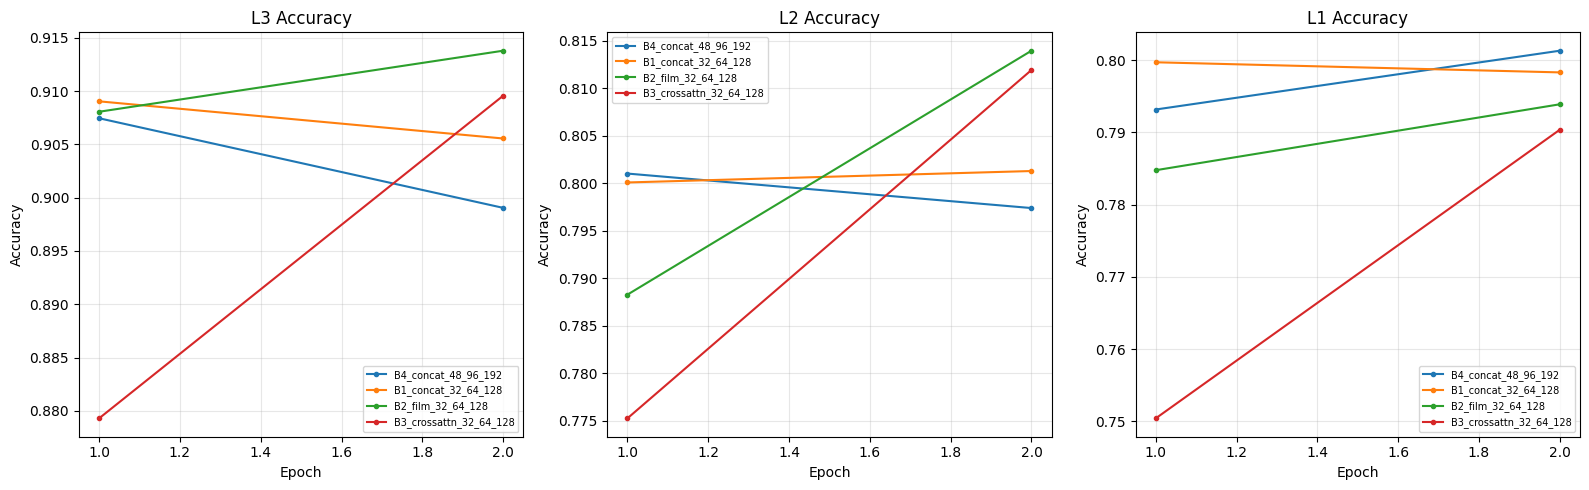

In [13]:
# ── Per-level accuracy learning curves ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for run_name in summary_df["model"].tolist():
    sub = history_df[history_df["model"] == run_name]
    axes[0].plot(sub["epoch"], sub["acc_L3"], label=f"{run_name}", marker="o", ms=3)
    axes[1].plot(sub["epoch"], sub["acc_L2"], label=f"{run_name}", marker="o", ms=3)
    axes[2].plot(sub["epoch"], sub["acc_L1"], label=f"{run_name}", marker="o", ms=3)

for i, lv in enumerate(["L3", "L2", "L1"]):
    axes[i].set(title=f"{lv} Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

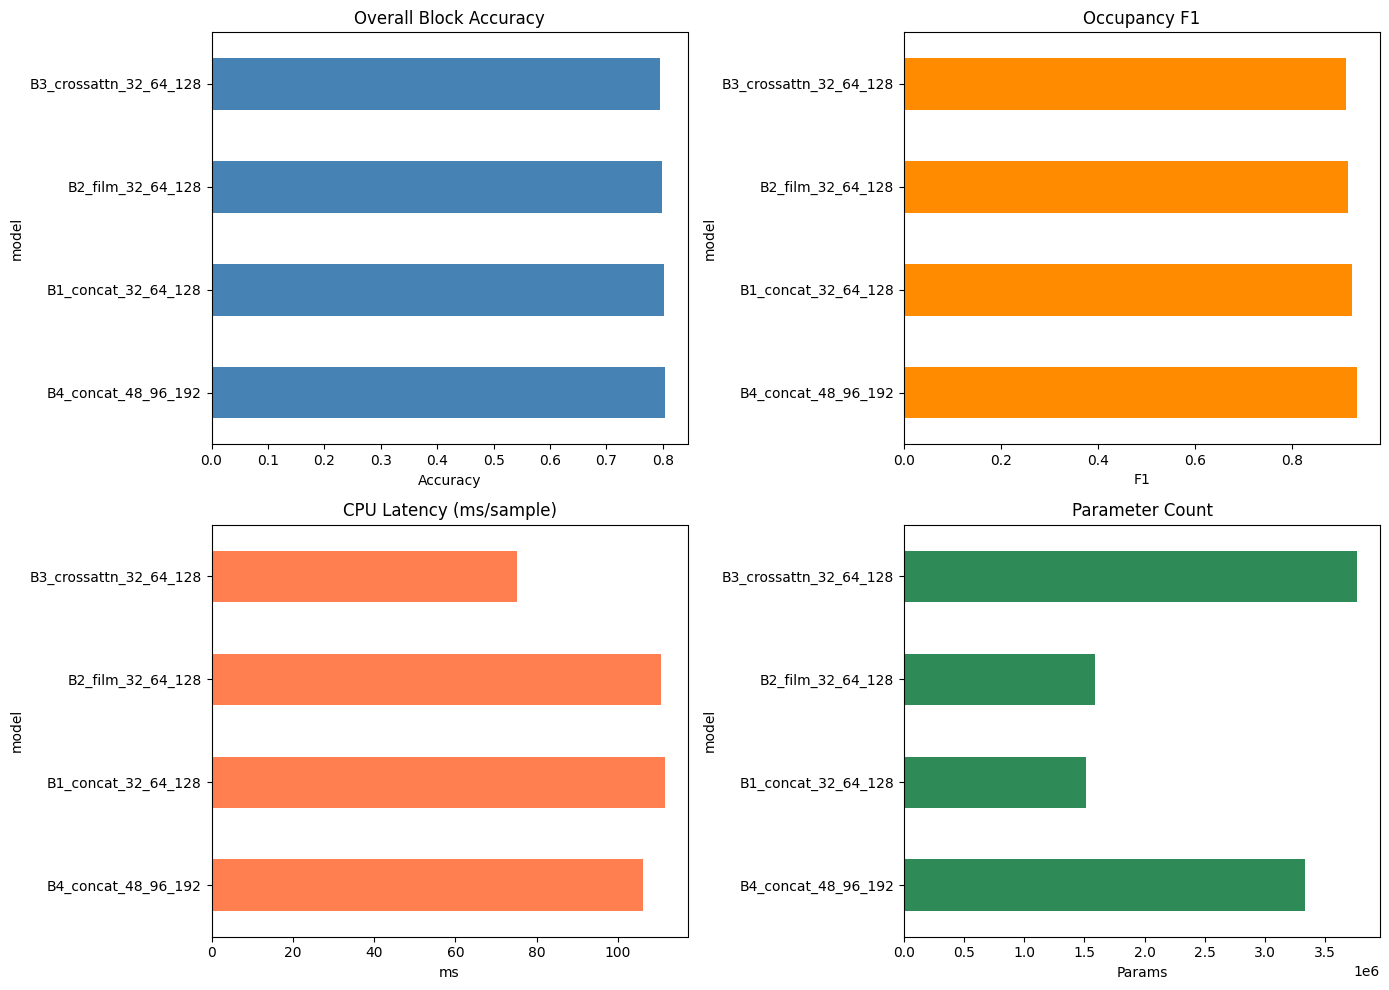

In [14]:
# ── Bar chart comparison ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

summary_df.plot.barh(y="block_acc", x="model", ax=axes[0, 0], legend=False, color="steelblue")
axes[0, 0].set(title="Overall Block Accuracy", xlabel="Accuracy")

summary_df.plot.barh(y="occ_f1", x="model", ax=axes[0, 1], legend=False, color="darkorange")
axes[0, 1].set(title="Occupancy F1", xlabel="F1")

summary_df.plot.barh(y="ms_per_sample", x="model", ax=axes[1, 0], legend=False, color="coral")
axes[1, 0].set(title="CPU Latency (ms/sample)", xlabel="ms")

summary_df.plot.barh(y="params", x="model", ax=axes[1, 1], legend=False, color="seagreen")
axes[1, 1].set(title="Parameter Count", xlabel="Params")

plt.tight_layout()
plt.show()

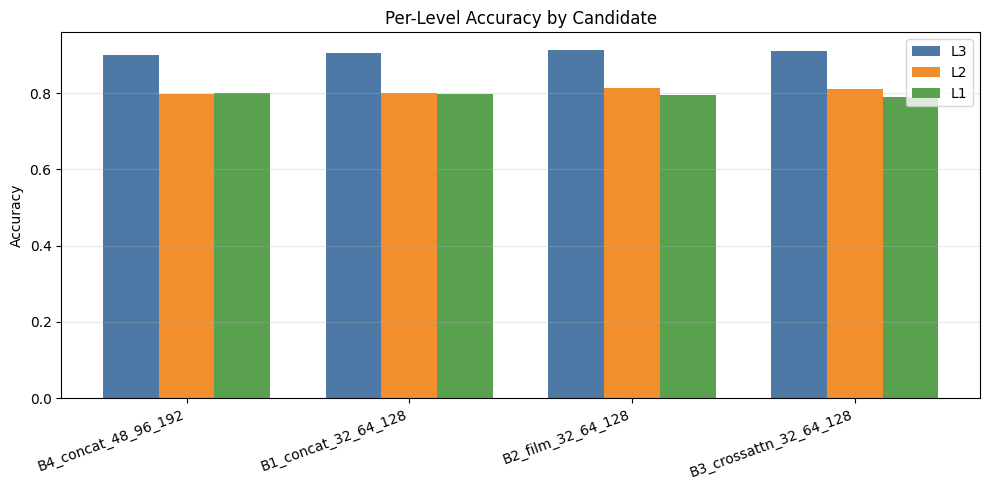

In [15]:
# ── Per-level accuracy grouped bar chart ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary_df))
w = 0.25
ax.bar(x - w, summary_df["acc_L3"], w, label="L3", color="#4e79a7")
ax.bar(x, summary_df["acc_L2"], w, label="L2", color="#f28e2b")
ax.bar(x + w, summary_df["acc_L1"], w, label="L1", color="#59a14f")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["model"], rotation=20, ha="right")
ax.set(title="Per-Level Accuracy by Candidate", ylabel="Accuracy")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Level Embedding Secondary Test

Test 3 level embedding strategies on the winning parent conditioning architecture:
1. **Additive**: level → embedding → project to channel dim → add to encoder features
2. **Concat**: level → embedding → repeat to spatial → concatenate as extra channel
3. **FiLM**: level → embedding → generate γ, β → modulate BN outputs

In [16]:
class ConcatParentUNet_LevelConcat(nn.Module):
    """B1 variant: level embedding concatenated as extra input channel."""

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
        level_dim: int = 8,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, level_dim)

        # Input is c0 + level_dim (level is concatenated as extra channels)
        self.enc1 = DoubleConv3d(c0 + level_dim, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)

        # Level embedding concatenated as spatial broadcast
        le = self.level_emb(batch["level"].clamp(0, NUM_LEVELS - 1))
        le_vol = le.view(-1, le.shape[1], 1, 1, 1).expand(-1, -1, SPATIAL, SPATIAL, SPATIAL)
        x = torch.cat([x, le_vol], dim=1)

        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {"block_logits": self.block_head(d1), "occ_logits": self.occ_head(bn)}


class ConcatParentUNet_LevelFiLM(nn.Module):
    """B1 variant: level embedding applied via FiLM modulation on encoder BN."""

    LEVEL_DIM = 32

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, self.LEVEL_DIM)

        self.conv1a = nn.Conv3d(c0, c0, 3, padding=1, bias=False)
        self.film1 = FiLMLayer3d(c0, self.LEVEL_DIM)
        self.conv1b = nn.Conv3d(c0, c0, 3, padding=1, bias=False)
        self.film1b = FiLMLayer3d(c0, self.LEVEL_DIM)
        self.pool1 = nn.MaxPool3d(2)

        self.conv2a = nn.Conv3d(c0, c1, 3, padding=1, bias=False)
        self.film2 = FiLMLayer3d(c1, self.LEVEL_DIM)
        self.conv2b = nn.Conv3d(c1, c1, 3, padding=1, bias=False)
        self.film2b = FiLMLayer3d(c1, self.LEVEL_DIM)
        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv3d(c1, c2)

        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)

        le = self.level_emb(batch["level"].clamp(0, NUM_LEVELS - 1))

        s1 = F.relu(self.film1(self.conv1a(x), le))
        s1 = F.relu(self.film1b(self.conv1b(s1), le))

        s2 = F.relu(self.film2(self.conv2a(self.pool1(s1)), le))
        s2 = F.relu(self.film2b(self.conv2b(s2), le))

        bn = self.enc3(self.pool2(s2))

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {"block_logits": self.block_head(d1), "occ_logits": self.occ_head(bn)}


# ----- Run level embedding comparison on the concat architecture -----
LEVEL_EMB_CANDIDATES = {
    "level_additive": lambda: ConcatParentUNet(c0=32, c1=64, c2=128),
    "level_concat": lambda: ConcatParentUNet_LevelConcat(c0=32, c1=64, c2=128),
    "level_film": lambda: ConcatParentUNet_LevelFiLM(c0=32, c1=64, c2=128),
}

level_histories = []
level_summary_rows = []

print("\n" + "━" * 60)
print("  LEVEL EMBEDDING COMPARISON (on concat parent arch)")
print("━" * 60)

for name, make_model in LEVEL_EMB_CANDIDATES.items():
    model = make_model()
    n_params = sum(p.numel() for p in model.parameters())
    print(f'\n{"═" * 50}')
    print(f"  {name}  ({n_params:,} params)")
    print(f'{"═" * 50}')

    trained_model, hist = train_candidate(name, model, train_loader, val_loader, epochs=EPOCHS)
    level_histories.append(hist)

    lat = benchmark_latency(trained_model, val_loader, device="cpu")
    best = hist.loc[hist["val_loss"].idxmin()]
    level_summary_rows.append(
        {
            "model": name,
            "params": n_params,
            "block_acc": best["block_acc"],
            "acc_L3": best["acc_L3"],
            "acc_L2": best["acc_L2"],
            "acc_L1": best["acc_L1"],
            "occ_f1": best["occ_f1"],
            "ms_per_sample": lat["ms_per_sample"],
        }
    )

level_summary_df = pd.DataFrame(level_summary_rows).sort_values("block_acc", ascending=False)
print("\n\nLevel embedding comparison:")
print(level_summary_df.to_string(index=False))
level_summary_df


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LEVEL EMBEDDING COMPARISON (on concat parent arch)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

══════════════════════════════════════════════════
  level_additive  (1,512,353 params)
══════════════════════════════════════════════════
  ✓ Initialized level_additive.block_head bias from log-frequency priors
  [level_additive] ep  1  loss=1.0634  acc=0.7729  L3=0.9058  L2=0.7860  L1=0.7674  occ_f1=0.9181

══════════════════════════════════════════════════
  level_concat  (1,515,417 params)
══════════════════════════════════════════════════
  ✓ Initialized level_concat.block_head bias from log-frequency priors
  [level_concat] ep  1  loss=1.0825  acc=0.7957  L3=0.9008  L2=0.7935  L1=0.7929  occ_f1=0.9159

══════════════════════════════════════════════════
  level_film  (1,521,297 params)
══════════════════════════════════════════════════
  ✓ Initialized level_film.block_head bias from log-frequency priors
  [

,model,params,block_acc,acc_L3,acc_L2,acc_L1,occ_f1,ms_per_sample
2,level_film,1521297,0.807840,0.909430,0.790906,0.806850,0.918280,68.622209
1,level_concat,1515417,0.796368,0.911182,0.799115,0.792689,0.917785,71.307237
0,level_additive,1512353,0.790830,0.904865,0.790251,0.787564,0.923954,67.835438


## CPU Inference Timing

                 model  ms_per_batch  ms_per_sample
   B1_concat_32_64_128    539.730823      67.466353
     B2_film_32_64_128    565.664983      70.708123
B3_crossattn_32_64_128    641.293677      80.161710
   B4_concat_48_96_192    848.467010     106.058376


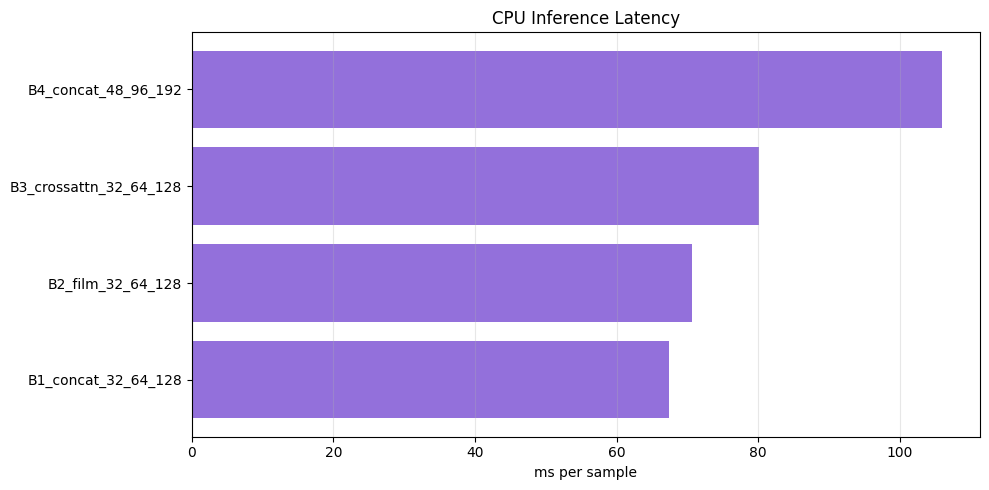

In [17]:
timing_rows = []
for run_name, model in trained_models.items():
    lat = benchmark_latency(model, val_loader, device="cpu", warmup=10, steps=30)
    timing_rows.append({"model": run_name, **lat})

timing_df = pd.DataFrame(timing_rows).sort_values("ms_per_sample")
print(timing_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(timing_df["model"], timing_df["ms_per_sample"], color="mediumpurple")
ax.set(title="CPU Inference Latency", xlabel="ms per sample")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Save Winner and Artifacts

In [18]:
winner_row = summary_df.iloc[0]
winner_name = winner_row["model"]
print(f"Winner: {winner_name}")
print(
    f'  block_acc={winner_row["block_acc"]:.4f}  L3={winner_row["acc_L3"]:.4f}  '
    f'L2={winner_row["acc_L2"]:.4f}  L1={winner_row["acc_L1"]:.4f}'
)
print(
    f'  occ_f1={winner_row["occ_f1"]:.4f}  params={winner_row["params"]:,}  '
    f'ms/sample={winner_row["ms_per_sample"]:.2f}'
)

save_path = ARTIFACT_DIR / f"octree_refine_{winner_name}_state_dict.pt"
torch.save(trained_models[winner_name].state_dict(), save_path)
print(f"\nSaved → {save_path}")

csv_path = ARTIFACT_DIR / "octree_refine_shootout_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Summary → {csv_path}")

hist_path = ARTIFACT_DIR / "octree_refine_shootout_history.csv"
history_df.to_csv(hist_path, index=False)
print(f"History → {hist_path}")

Winner: B4_concat_48_96_192
  block_acc=0.8034  L3=0.8990  L2=0.7974  L1=0.8013
  occ_f1=0.9356  params=3,336,225  ms/sample=106.16

Saved → c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\octree_refine_B4_concat_48_96_192_state_dict.pt
Summary → c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\octree_refine_shootout_summary.csv
History → c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\octree_refine_shootout_history.csv


## Summary & Recommendations

### Key Questions Answered

1. **How should parent context be injected?** Compare concat (B1/B4) vs FiLM (B2) vs cross-attention (B3).
   - Concat is simplest; FiLM adds multiplicative interaction; cross-attention is most expressive.
2. **Does wider beat smarter?** B4 (wider concat) vs B2/B3 (smarter injection, narrower).
3. **Does the shared model handle all levels equally?** Check L3 vs L2 vs L1 accuracy.
   If L1 accuracy is much lower, we may need level-specific capacity.
4. **What's the latency cost of expressiveness?** Cross-attention may not be worth the compute
   if concat works nearly as well.
5. **Best level embedding strategy?** Additive vs concat vs FiLM — does it even matter much?

### Decision Criteria (ordered priority)

1. **Overall block_acc** ≥ 1pp gap → winner
2. **Per-level uniformity**: prefer models with consistent L3/L2/L1 accuracy
3. Tie: fewer params → winner
4. Tie: lower latency → winner

### Next Steps
- Take the winning parent conditioning strategy to the leaf model
- Test on real Voxy data with proper parent-child relationships
- Export the winner to ONNX for Java integration testing

# Legacy duplicate section — do not run

The updated refine shootout ends above at **Summary & Recommendations**.
Everything below this heading is an older appended copy retained only for reference.

In [19]:
raise RuntimeError(
    "Legacy duplicate section reached. Stop here and use the updated refine shootout cells above."
)

RuntimeError: Legacy duplicate section reached. Stop here and use the updated refine shootout cells above.

## Data Loading / Synthetic Generation

Generate synthetic L3/L2/L1 training data with parent context. Each sample includes:
- `labels32`: target 32³ block IDs
- `parent_labels32`: parent octant upsampled 2× to 32³
- `heightmap32`: 5-channel height features
- `biome32`: biome indices
- `y_position`: section Y coordinate
- `level`: LOD level (1, 2, or 3)
- `non_empty_children`: 8-bit occupancy mask

Parent context is a **coarser version** of the target — same structure but with
details stripped (e.g., some blocks merged to dominant type).

In [ ]:
AIR = 0
STONE = 1
DIRT = 3
GRASS_BLOCK = 9
SAND = 66
WATER = 34
DEEPSLATE = 899

# Voxel size per level (in blocks)
VOXEL_SIZE = {4: 16, 3: 8, 2: 4, 1: 2, 0: 1}


def generate_smooth_heightmap(n: int, size: int = 32) -> np.ndarray:
    """Generate plausible heightmaps with 5 channels."""
    xs = np.linspace(0, 4 * np.pi, size)
    zs = np.linspace(0, 4 * np.pi, size)
    xg, zg = np.meshgrid(xs, zs, indexing="ij")
    heights = np.zeros((n, 5, size, size), dtype=np.float32)
    for i in range(n):
        phase_x, phase_z = random.uniform(0, 2 * np.pi), random.uniform(0, 2 * np.pi)
        base_h = random.uniform(50, 80)
        surface = (
            base_h
            + random.uniform(8, 20) * np.sin(random.uniform(0.5, 1.5) * xg + phase_x)
            + random.uniform(2, 6) * np.sin(random.uniform(1.5, 3.0) * zg + phase_z)
        )
        ocean = np.full_like(surface, 63.0)
        slope_x = np.gradient(surface, axis=0)
        slope_z = np.gradient(surface, axis=1)
        curvature = np.gradient(slope_x, axis=0) + np.gradient(slope_z, axis=1)
        heights[i, 0] = surface / 320.0
        heights[i, 1] = ocean / 320.0
        heights[i, 2] = slope_x / 10.0
        heights[i, 3] = slope_z / 10.0
        heights[i, 4] = curvature / 20.0
    return heights


def generate_biomes(n: int, size: int = 32) -> np.ndarray:
    biomes = np.zeros((n, size, size), dtype=np.int32)
    common = [1, 4, 5, 6, 21, 27, 29, 35, 38, 132, 162, 163]
    for i in range(n):
        base = random.choice(common)
        biomes[i] = base
        if random.random() > 0.5:
            split = random.randint(8, 24)
            biomes[i, split:, :] = random.choice(common)
    return biomes


def generate_refine_blocks(heightmap: np.ndarray, level: int, size: int = 32):
    """Generate target blocks and a coarser parent version.

    The target has finer detail; the parent is a downsampled-then-upsampled
    version simulating what the parent model would have predicted.
    """
    n = heightmap.shape[0]
    voxel_size = VOXEL_SIZE[level]
    labels = np.full((n, size, size, size), AIR, dtype=np.int32)
    parent = np.full((n, size, size, size), AIR, dtype=np.int32)
    nec = np.zeros(n, dtype=np.uint8)

    for i in range(n):
        surface = heightmap[i, 0] * 320.0
        y_off = random.randint(0, 10) * voxel_size * size  # world Y offset

        # Generate target blocks (finer detail)
        for y in range(size):
            world_y = y_off + y * voxel_size + voxel_size // 2
            for x in range(size):
                for z in range(size):
                    h = surface[x, z]
                    if world_y < h - 20:
                        labels[i, y, x, z] = STONE
                    elif world_y < h - 5:
                        labels[i, y, x, z] = DIRT
                    elif world_y < h:
                        labels[i, y, x, z] = GRASS_BLOCK
                    elif world_y < 63:
                        labels[i, y, x, z] = WATER
                    else:
                        labels[i, y, x, z] = AIR

        # Generate parent context (coarser version — downsample 2× then upsample)
        # Take every other voxel (16³ subsample) then repeat_interleave to 32³
        coarse = labels[i, ::2, ::2, ::2]  # (16, 16, 16)
        parent[i] = np.repeat(np.repeat(np.repeat(coarse, 2, axis=0), 2, axis=1), 2, axis=2)

        # Add some noise to parent to simulate imperfect predictions
        noise_mask = np.random.random((size, size, size)) < 0.05
        noise_blocks = np.random.choice([AIR, STONE, DIRT], size=(size, size, size))
        parent[i] = np.where(noise_mask, noise_blocks, parent[i])

        # Compute non_empty_children
        mask = 0
        half = size // 2
        for oct_idx in range(8):
            ox = (oct_idx & 1) * half
            oz = ((oct_idx >> 1) & 1) * half
            oy = ((oct_idx >> 2) & 1) * half
            if np.any(labels[i, oy : oy + half, ox : ox + half, oz : oz + half] != AIR):
                mask |= 1 << oct_idx
        nec[i] = mask

    return labels, parent, nec


def load_or_generate_refine_data(
    n_per_level: int = 800,
    n_val_per_level: int = 200,
    use_real_data: bool = False,
) -> tuple[dict, dict]:
    """Generate synthetic data for L3, L2, L1 and combine."""
    if use_real_data and DATA_DIR.exists():
        candidates = sorted(DATA_DIR.glob("refine_train_*.npz"))
        if candidates:
            print(f"Loading real data from {candidates[-1]}")
            return dict(np.load(candidates[-1])), dict(
                np.load(sorted(DATA_DIR.glob("refine_val_*.npz"))[-1])
            )

    print(
        f"Generating synthetic refine data: {n_per_level}/level train, {n_val_per_level}/level val"
    )
    splits = {}
    for split_name, n in [("train", n_per_level), ("val", n_val_per_level)]:
        all_labels, all_parent, all_hm, all_biome, all_y, all_level, all_nec = (
            [],
            [],
            [],
            [],
            [],
            [],
            [],
        )
        for level in [3, 2, 1]:
            hm = generate_smooth_heightmap(n)
            biomes = generate_biomes(n)
            y_pos = np.random.randint(0, NUM_Y_POSITIONS, size=n).astype(np.int64)
            labels, parent, nec = generate_refine_blocks(hm, level)
            all_labels.append(labels)
            all_parent.append(parent)
            all_hm.append(hm)
            all_biome.append(biomes)
            all_y.append(y_pos)
            all_level.append(np.full(n, level, dtype=np.int64))
            all_nec.append(nec)

        splits[split_name] = {
            "labels32": np.concatenate(all_labels),
            "parent_labels32": np.concatenate(all_parent),
            "heightmap32": np.concatenate(all_hm),
            "biome32": np.concatenate(all_biome),
            "y_position": np.concatenate(all_y),
            "level": np.concatenate(all_level),
            "non_empty_children": np.concatenate(all_nec),
        }
    return splits["train"], splits["val"]


train_data, val_data = load_or_generate_refine_data(n_per_level=800, n_val_per_level=200)

for name, d in [("train", train_data), ("val", val_data)]:
    print(f"{name}:")
    for k, v in d.items():
        print(f"  {k}: shape={v.shape} dtype={v.dtype}")
    level_dist = pd.Series(d["level"]).value_counts().sort_index()
    print(f"  levels: {dict(level_dist)}")

In [ ]:
# ── Data sanity checks ─────────────────────────────────────────────
labels = train_data["labels32"]
parent = train_data["parent_labels32"]
print(f"Air fraction (target): {(labels == AIR).mean():.3f}")
print(f"Air fraction (parent): {(parent == AIR).mean():.3f}")
print(f"Parent-target agreement: {(labels == parent).mean():.3f}")
print(
    f'Non-empty children mean bits: {np.mean([bin(x).count("1") for x in train_data["non_empty_children"]]):.1f}'
)

In [ ]:
class OctreeRefineDataset(Dataset):
    """Dataset for Model B (L3-L1 shared refine)."""

    def __init__(self, data: dict):
        self.labels = torch.from_numpy(data["labels32"]).long()
        self.parent = torch.from_numpy(data["parent_labels32"]).long()
        self.heightmap = torch.from_numpy(data["heightmap32"]).float()
        self.biome = torch.from_numpy(data["biome32"]).long()
        self.y_pos = torch.from_numpy(data["y_position"]).long()
        self.level = torch.from_numpy(data["level"]).long()
        self.nec = torch.from_numpy(data["non_empty_children"]).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "labels32": self.labels[idx],
            "parent_labels32": self.parent[idx],
            "heightmap32": self.heightmap[idx],
            "biome32": self.biome[idx],
            "y_position": self.y_pos[idx],
            "level": self.level[idx],
            "non_empty_children": self.nec[idx],
        }


def make_loader(data: dict, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        OctreeRefineDataset(data),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=True,
    )


BATCH_SIZE = 8
train_loader = make_loader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_data, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"{k}: {tuple(v.shape)} {v.dtype}")

## Building Blocks

Shared components for the refine model candidates.

In [ ]:
class Conv3dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DoubleConv3d(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(Conv3dBlock(in_ch, out_ch), Conv3dBlock(out_ch, out_ch))

    def forward(self, x):
        return self.block(x)


class OccupancyHead(nn.Module):
    def __init__(self, in_ch: int):
        super().__init__()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(in_ch, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 8),
        )

    def forward(self, x):
        return self.head(x)


class ParentEncoder(nn.Module):
    """Encode parent_labels32 (int32, 32³) into a dense feature volume.

    Embeds each parent block ID, then applies a lightweight 3D conv to
    smooth the embedding field.
    """

    def __init__(self, out_ch: int, embed_dim: int = 16):
        super().__init__()
        self.block_emb = nn.Embedding(NUM_BLOCK_CLASSES, embed_dim)
        self.conv = nn.Sequential(
            nn.Conv3d(embed_dim, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, parent_labels: torch.Tensor) -> torch.Tensor:
        # parent_labels: (B, 32, 32, 32) int
        emb = self.block_emb(
            parent_labels.clamp(0, NUM_BLOCK_CLASSES - 1)
        )  # (B,32,32,32,embed_dim)
        emb = emb.permute(0, 4, 1, 2, 3)  # (B, embed_dim, 32, 32, 32)
        return self.conv(emb)


class ConditioningEncoder2D(nn.Module):
    """Encode heightmap + biome → 2D feature map, then expand to 3D."""

    def __init__(self, out_ch: int, biome_dim: int = 8, y_dim: int = 8):
        super().__init__()
        self.biome_emb = nn.Embedding(NUM_BIOMES, biome_dim)
        self.y_emb = nn.Embedding(NUM_Y_POSITIONS, y_dim)
        self.conv2d = nn.Sequential(
            nn.Conv2d(5 + biome_dim, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.y_proj = nn.Linear(y_dim, out_ch)

    def forward(self, hm, biome, y_pos):
        B = hm.shape[0]
        biome_feat = self.biome_emb(biome.clamp(0, NUM_BIOMES - 1)).permute(0, 3, 1, 2)
        cond_2d = self.conv2d(torch.cat([hm, biome_feat], dim=1))
        cond_3d = cond_2d.unsqueeze(2).expand(-1, -1, SPATIAL, -1, -1)
        y_feat = self.y_proj(self.y_emb(y_pos.clamp(0, NUM_Y_POSITIONS - 1))).view(B, -1, 1, 1, 1)
        return cond_3d + y_feat


print("Building blocks defined.")

## Candidate 1: Concatenation Parent Injection (`concat_parent`)

Simplest approach: embed parent block IDs into a feature volume, then concatenate
with heightmap/biome conditioning as input channels to the 3D U-Net. Level embedding
is added to all encoder features.

In [ ]:
class ConcatParentUNet(nn.Module):
    """Parent context concatenated as input channels + additive level embedding."""

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
        level_dim: int = 16,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, level_dim)
        self.level_proj0 = nn.Linear(level_dim, c0)
        self.level_proj1 = nn.Linear(level_dim, c1)
        self.level_proj2 = nn.Linear(level_dim, c2)

        # Encoder
        self.enc1 = DoubleConv3d(c0, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)  # (B, c0, 32, 32, 32)

        level = batch["level"].clamp(0, NUM_LEVELS - 1)
        le = self.level_emb(level)

        s1 = self.enc1(x)
        s1 = s1 + self.level_proj0(le).view(-1, s1.shape[1], 1, 1, 1)

        s2 = self.enc2(self.pool1(s1))
        s2 = s2 + self.level_proj1(le).view(-1, s2.shape[1], 1, 1, 1)

        bn = self.enc3(self.pool2(s2))
        bn = bn + self.level_proj2(le).view(-1, bn.shape[1], 1, 1, 1)

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {
            "block_logits": self.block_head(d1),
            "occ_logits": self.occ_head(bn),
        }


_m = ConcatParentUNet(c0=24, c1=48, c2=96)
with torch.no_grad():
    _out = _m(batch)
print("ConcatParentUNet:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

## Candidate 2: FiLM Parent Injection (`film_parent`)

Uses Feature-wise Linear Modulation: parent features generate per-channel
scale (γ) and shift (β) that modulate the BatchNorm outputs.
This allows multiplicative interaction between parent context and learned features.

Level embedding is also injected via FiLM modulation.

In [ ]:
class FiLMLayer3d(nn.Module):
    """Feature-wise Linear Modulation for 3D feature maps."""

    def __init__(self, num_features: int, cond_dim: int):
        super().__init__()
        self.norm = nn.BatchNorm3d(num_features)
        self.gamma = nn.Linear(cond_dim, num_features)
        self.beta = nn.Linear(cond_dim, num_features)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        g = self.gamma(cond).view(-1, x.shape[1], 1, 1, 1)
        b = self.beta(cond).view(-1, x.shape[1], 1, 1, 1)
        return (1 + g) * self.norm(x) + b


class FiLMParentUNet(nn.Module):
    """FiLM-conditioned U-Net: parent + level features modulate conv layers."""

    COND_DIM = 64

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond_enc = ConditioningEncoder2D(out_ch=c0)
        self.parent_enc = ParentEncoder(out_ch=c0, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, 16)

        # Build conditioning vector from parent features + level
        self.cond_net = nn.Sequential(
            nn.Linear(c0 + 16, self.COND_DIM * 2),
            nn.ReLU(inplace=True),
            nn.Linear(self.COND_DIM * 2, self.COND_DIM),
            nn.ReLU(inplace=True),
        )

        # Encoder with FiLM layers
        self.conv1a = nn.Conv3d(c0, c0, 3, padding=1, bias=False)
        self.film1a = FiLMLayer3d(c0, self.COND_DIM)
        self.conv1b = nn.Conv3d(c0, c0, 3, padding=1, bias=False)
        self.film1b = FiLMLayer3d(c0, self.COND_DIM)
        self.pool1 = nn.MaxPool3d(2)

        self.conv2a = nn.Conv3d(c0, c1, 3, padding=1, bias=False)
        self.film2a = FiLMLayer3d(c1, self.COND_DIM)
        self.conv2b = nn.Conv3d(c1, c1, 3, padding=1, bias=False)
        self.film2b = FiLMLayer3d(c1, self.COND_DIM)
        self.pool2 = nn.MaxPool3d(2)

        self.conv3a = nn.Conv3d(c1, c2, 3, padding=1, bias=False)
        self.film3a = FiLMLayer3d(c2, self.COND_DIM)
        self.conv3b = nn.Conv3d(c2, c2, 3, padding=1, bias=False)
        self.film3b = FiLMLayer3d(c2, self.COND_DIM)

        # Decoder (standard — no FiLM)
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        x = self.cond_enc(batch["heightmap32"], batch["biome32"], batch["y_position"])

        # Build FiLM conditioning vector
        parent_feat = self.parent_enc(batch["parent_labels32"])  # (B, c0, 32, 32, 32)
        parent_global = F.adaptive_avg_pool3d(parent_feat, 1).flatten(1)  # (B, c0)
        level_feat = self.level_emb(batch["level"].clamp(0, NUM_LEVELS - 1))  # (B, 16)
        cond = self.cond_net(torch.cat([parent_global, level_feat], dim=1))  # (B, COND_DIM)

        # Also add parent as additive input
        x = x + parent_feat

        # Encoder with FiLM
        s1 = F.relu(self.film1a(self.conv1a(x), cond))
        s1 = F.relu(self.film1b(self.conv1b(s1), cond))

        s2 = F.relu(self.film2a(self.conv2a(self.pool1(s1)), cond))
        s2 = F.relu(self.film2b(self.conv2b(s2), cond))

        bn = F.relu(self.film3a(self.conv3a(self.pool2(s2)), cond))
        bn = F.relu(self.film3b(self.conv3b(bn), cond))

        # Decoder
        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {
            "block_logits": self.block_head(d1),
            "occ_logits": self.occ_head(bn),
        }


_m = FiLMParentUNet(c0=24, c1=48, c2=96)
with torch.no_grad():
    _out = _m(batch)
print("FiLMParentUNet:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

## Candidate 3: Cross-Attention Parent Injection (`crossattn_parent`)

Most expressive: decoder features attend over parent context using
multi-head cross-attention at the bottleneck. This allows the model
to selectively focus on different parts of the parent prediction.

In [ ]:
class SpatialCrossAttention3d(nn.Module):
    """Cross-attention between 3D feature maps.

    Reshapes spatial dims to sequence for attention, then back to 3D.
    """

    def __init__(self, dim: int, n_heads: int = 4):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)

    def forward(self, query: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        B, C, D, H, W = query.shape
        q = query.flatten(2).permute(0, 2, 1)  # (B, D*H*W, C)
        kv = context.flatten(2).permute(0, 2, 1)  # (B, D*H*W, C)
        q = self.norm_q(q)
        kv = self.norm_kv(kv)
        out, _ = self.attn(q, kv, kv)
        return out.permute(0, 2, 1).view(B, C, D, H, W)


class CrossAttnParentUNet(nn.Module):
    """Cross-attention parent conditioning at the bottleneck."""

    def __init__(
        self,
        c0: int = 32,
        c1: int = 64,
        c2: int = 128,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond_enc = ConditioningEncoder2D(out_ch=c0)
        self.parent_enc = ParentEncoder(out_ch=c0, embed_dim=parent_dim)
        self.level_emb = nn.Embedding(NUM_LEVELS, c0)

        # Encoder
        self.enc1 = DoubleConv3d(c0 * 2, c0)  # conditioning + parent
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        # Parent encoder (separate branch for cross-attention context)
        self.parent_down = nn.Sequential(
            nn.MaxPool3d(2),  # 32→16
            DoubleConv3d(c0, c1),
            nn.MaxPool3d(2),  # 16→8
            DoubleConv3d(c1, c2),
        )

        # Cross-attention at bottleneck (8³)
        self.cross_attn = SpatialCrossAttention3d(c2, n_heads=4)
        self.post_attn = DoubleConv3d(c2 * 2, c2)  # cat(bn, attn_out) → refine

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2)

    def forward(self, batch: dict) -> dict:
        cond = self.cond_enc(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])

        # Add level embedding
        level_feat = self.level_emb(batch["level"].clamp(0, NUM_LEVELS - 1))
        cond = cond + level_feat.view(-1, cond.shape[1], 1, 1, 1)

        x = torch.cat([cond, parent_feat], dim=1)  # (B, c0*2, 32, 32, 32)

        # Encoder
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))

        # Cross-attention: decoder attends over downsampled parent
        parent_ctx = self.parent_down(parent_feat)  # (B, c2, 8, 8, 8)
        attn_out = self.cross_attn(bn, parent_ctx)
        bn = self.post_attn(torch.cat([bn, attn_out], dim=1))

        # Decoder
        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {
            "block_logits": self.block_head(d1),
            "occ_logits": self.occ_head(bn),
        }


_m = CrossAttnParentUNet(c0=24, c1=48, c2=96)
with torch.no_grad():
    _out = _m(batch)
print("CrossAttnParentUNet:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

## Training Infrastructure

In [ ]:
def unpack_occ_bits(nec: torch.Tensor) -> torch.Tensor:
    bits = [((nec >> b) & 1).float() for b in range(8)]
    return torch.stack(bits, dim=1)


def compute_loss(model_out: dict, batch: dict) -> tuple[torch.Tensor, dict]:
    block_logits = model_out["block_logits"]
    B, C = block_logits.shape[:2]
    block_loss = F.cross_entropy(
        block_logits.permute(0, 2, 3, 4, 1).reshape(-1, C),
        batch["labels32"].reshape(-1),
    )
    metrics = {"block_loss": block_loss.item()}
    total = block_loss

    if "occ_logits" in model_out:
        occ_target = unpack_occ_bits(batch["non_empty_children"]).to(block_logits.device)
        occ_loss = F.binary_cross_entropy_with_logits(model_out["occ_logits"], occ_target)
        total = total + 0.5 * occ_loss
        metrics["occ_loss"] = occ_loss.item()

    metrics["total_loss"] = total.item()
    return total, metrics


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    total_loss_sum = 0.0
    # Per-level stats
    level_correct = {1: 0, 2: 0, 3: 0}
    level_total = {1: 0, 2: 0, 3: 0}
    block_correct = 0
    total_voxels = 0
    occ_tp, occ_fp, occ_fn = 0, 0, 0

    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(batch)
        loss, _ = compute_loss(out, batch)
        B = batch["labels32"].shape[0]
        total_loss_sum += loss.item() * B

        logits = out["block_logits"]
        C = logits.shape[1]
        pred = logits.permute(0, 2, 3, 4, 1).reshape(B, -1, C).argmax(dim=2)  # (B, 32768)
        target = batch["labels32"].reshape(B, -1)
        correct_mask = pred == target

        block_correct += correct_mask.sum().item()
        total_voxels += target.numel()

        # Per-level breakdown
        levels = batch["level"].cpu().numpy()
        for i in range(B):
            lv = int(levels[i])
            if lv in level_correct:
                level_correct[lv] += correct_mask[i].sum().item()
                level_total[lv] += correct_mask[i].numel()

        if "occ_logits" in out:
            occ_pred = (out["occ_logits"].sigmoid() > 0.5).cpu().numpy()
            occ_gt = unpack_occ_bits(batch["non_empty_children"]).cpu().numpy()
            occ_tp += ((occ_pred == 1) & (occ_gt == 1)).sum()
            occ_fp += ((occ_pred == 1) & (occ_gt == 0)).sum()
            occ_fn += ((occ_pred == 0) & (occ_gt == 1)).sum()

    results = {
        "val_loss": total_loss_sum / max(len(loader.dataset), 1),
        "block_acc": block_correct / max(total_voxels, 1),
    }
    for lv in [3, 2, 1]:
        results[f"acc_L{lv}"] = level_correct[lv] / max(level_total[lv], 1)

    precision = occ_tp / max(occ_tp + occ_fp, 1)
    recall = occ_tp / max(occ_tp + occ_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    results.update({"occ_precision": precision, "occ_recall": recall, "occ_f1": f1})
    return results


def train_candidate(
    name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 15,
    lr: float = 1e-3,
):
    model = model.to(DEVICE)
    init_block_head_bias(model, BLOCK_LOG_PRIORS, model_name=name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            loss, _ = compute_loss(model(batch), batch)
            loss.backward()
            optimizer.step()
            running += loss.item() * batch["labels32"].shape[0]
            seen += batch["labels32"].shape[0]
        scheduler.step()

        val_metrics = evaluate(model, val_loader)
        row = {"model": name, "epoch": epoch, "train_loss": running / max(seen, 1), **val_metrics}
        rows.append(row)
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  [{name}] ep {epoch:2d}  loss={row['train_loss']:.4f}  "
                f"acc={row['block_acc']:.4f}  L3={row['acc_L3']:.4f}  "
                f"L2={row['acc_L2']:.4f}  L1={row['acc_L1']:.4f}  occ_f1={row['occ_f1']:.4f}"
            )

    return model.cpu(), pd.DataFrame(rows)


@torch.no_grad()
def benchmark_latency(
    model: nn.Module, loader: DataLoader, warmup: int = 5, steps: int = 20, device: str = "cpu"
) -> dict:
    dev = torch.device(device)
    model = model.to(dev).eval()
    batch = {k: v.to(dev) for k, v in next(iter(loader)).items()}
    for _ in range(warmup):
        model(batch)
    t0 = time.perf_counter()
    for _ in range(steps):
        model(batch)
    ms_per_batch = (time.perf_counter() - t0) * 1000 / steps
    return {
        "ms_per_batch": ms_per_batch,
        "ms_per_sample": ms_per_batch / batch["labels32"].shape[0],
    }


print("Training infrastructure ready.")

## Shootout Runner

Sweep 3 architectures × 3 channel widths = **9 configurations**.
Each trains for 15 epochs.

In [ ]:
EPOCHS = 15
CHANNEL_CONFIGS = [
    ("small", 24, 48, 96),
    ("medium", 32, 64, 128),
    ("large", 48, 96, 192),
]

ARCH_CLASSES = {
    "concat_parent": ConcatParentUNet,
    "film_parent": FiLMParentUNet,
    "crossattn_parent": CrossAttnParentUNet,
}

all_histories = []
trained_models = {}
summary_rows = []

for arch_name, arch_cls in ARCH_CLASSES.items():
    for size_name, c0, c1, c2 in CHANNEL_CONFIGS:
        run_name = f"{arch_name}_{size_name}"
        model = arch_cls(c0=c0, c1=c1, c2=c2)
        n_params = sum(p.numel() for p in model.parameters())
        print(f'\n{"═"*60}')
        print(f"  {run_name}  ({n_params:,} params)")
        print(f'{"═"*60}')

        trained_model, hist = train_candidate(
            run_name, model, train_loader, val_loader, epochs=EPOCHS
        )
        all_histories.append(hist)
        trained_models[run_name] = trained_model

        lat = benchmark_latency(trained_model, val_loader, device="cpu")
        best = hist.loc[hist["val_loss"].idxmin()]
        summary_rows.append(
            {
                "model": run_name,
                "arch": arch_name,
                "channels": f"{c0}/{c1}/{c2}",
                "params": n_params,
                "best_epoch": int(best["epoch"]),
                "block_acc": best["block_acc"],
                "acc_L3": best["acc_L3"],
                "acc_L2": best["acc_L2"],
                "acc_L1": best["acc_L1"],
                "occ_f1": best["occ_f1"],
                "val_loss": best["val_loss"],
                "ms_per_sample": lat["ms_per_sample"],
            }
        )

history_df = pd.concat(all_histories, ignore_index=True)
summary_df = (
    pd.DataFrame(summary_rows).sort_values("block_acc", ascending=False).reset_index(drop=True)
)
print("\n\nDone.")

## Results Summary

In [ ]:
print(summary_df.to_string(index=False))
summary_df

In [ ]:
# ── Per-level accuracy comparison ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Best per arch
best_per_arch = summary_df.groupby("arch").first()["model"].tolist()

for run_name in best_per_arch:
    sub = history_df[history_df["model"] == run_name]
    axes[0].plot(sub["epoch"], sub["acc_L3"], label=f"{run_name} L3", marker="o", ms=3)
    axes[1].plot(sub["epoch"], sub["acc_L2"], label=f"{run_name} L2", marker="o", ms=3)
    axes[2].plot(sub["epoch"], sub["acc_L1"], label=f"{run_name} L1", marker="o", ms=3)

for i, lv in enumerate(["L3", "L2", "L1"]):
    axes[i].set(title=f"{lv} Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Bar chart comparison: accuracy vs latency vs params ──────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

summary_df.plot.barh(y="block_acc", x="model", ax=axes[0, 0], legend=False, color="steelblue")
axes[0, 0].set(title="Overall Block Accuracy", xlabel="Accuracy")

summary_df.plot.barh(y="occ_f1", x="model", ax=axes[0, 1], legend=False, color="darkorange")
axes[0, 1].set(title="Occupancy F1", xlabel="F1")

summary_df.plot.barh(y="ms_per_sample", x="model", ax=axes[1, 0], legend=False, color="coral")
axes[1, 0].set(title="CPU Latency (ms/sample)", xlabel="ms")

summary_df.plot.barh(y="params", x="model", ax=axes[1, 1], legend=False, color="seagreen")
axes[1, 1].set(title="Parameter Count", xlabel="Params")

plt.tight_layout()
plt.show()

In [ ]:
# ── Per-level accuracy grouped bar chart (best config per architecture) ──
fig, ax = plt.subplots(figsize=(10, 5))
best_rows = summary_df.groupby("arch").first().reset_index()
x = np.arange(len(best_rows))
w = 0.25
ax.bar(x - w, best_rows["acc_L3"], w, label="L3", color="#4e79a7")
ax.bar(x, best_rows["acc_L2"], w, label="L2", color="#f28e2b")
ax.bar(x + w, best_rows["acc_L1"], w, label="L1", color="#59a14f")
ax.set_xticks(x)
ax.set_xticklabels(best_rows["model"], rotation=20, ha="right")
ax.set(title="Per-Level Accuracy (best config per arch)", ylabel="Accuracy")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Save Winner and Artifacts

In [ ]:
winner_row = summary_df.iloc[0]
winner_name = winner_row["model"]
print(f"Winner: {winner_name}")
print(
    f'  block_acc={winner_row["block_acc"]:.4f}  L3={winner_row["acc_L3"]:.4f}  '
    f'L2={winner_row["acc_L2"]:.4f}  L1={winner_row["acc_L1"]:.4f}'
)
print(
    f'  occ_f1={winner_row["occ_f1"]:.4f}  params={winner_row["params"]:,}  '
    f'ms/sample={winner_row["ms_per_sample"]:.2f}'
)

save_path = ARTIFACT_DIR / f"octree_refine_{winner_name}_state_dict.pt"
torch.save(trained_models[winner_name].state_dict(), save_path)
print(f"\nSaved → {save_path}")

csv_path = ARTIFACT_DIR / "octree_refine_shootout_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Summary → {csv_path}")

hist_path = ARTIFACT_DIR / "octree_refine_shootout_history.csv"
history_df.to_csv(hist_path, index=False)
print(f"History → {hist_path}")

## Summary & Recommendations

### Key Questions Answered

- **How should parent context be injected?** Compare concat vs FiLM vs cross-attention.
  - Concat is simplest; FiLM adds multiplicative interaction; cross-attention is most expressive but slowest.
- **Does the shared model handle all levels equally?** Check L3 vs L2 vs L1 accuracy.
  - If L1 accuracy is much lower than L3, we may need a separate L1 model or more level-specific capacity.
- **What's the latency cost of expressiveness?** Cross-attention may not be worth the compute.

### Decision Criteria (ordered priority)

1. **Overall block_acc** ≥ 1pp gap → winner
2. **Per-level uniformity**: prefer models with consistent L3/L2/L1 accuracy
3. Tie: fewer params → winner
4. Tie: lower latency → winner

### Next Steps
- Take the winning parent conditioning strategy to the leaf model
- Test on real Voxy data with proper parent-child relationships
- Export the winner to ONNX for Java integration testing